In [48]:
import pandas as pd
df= pd.read_csv("cleaned_flights_sample_3m.csv", low_memory=False)

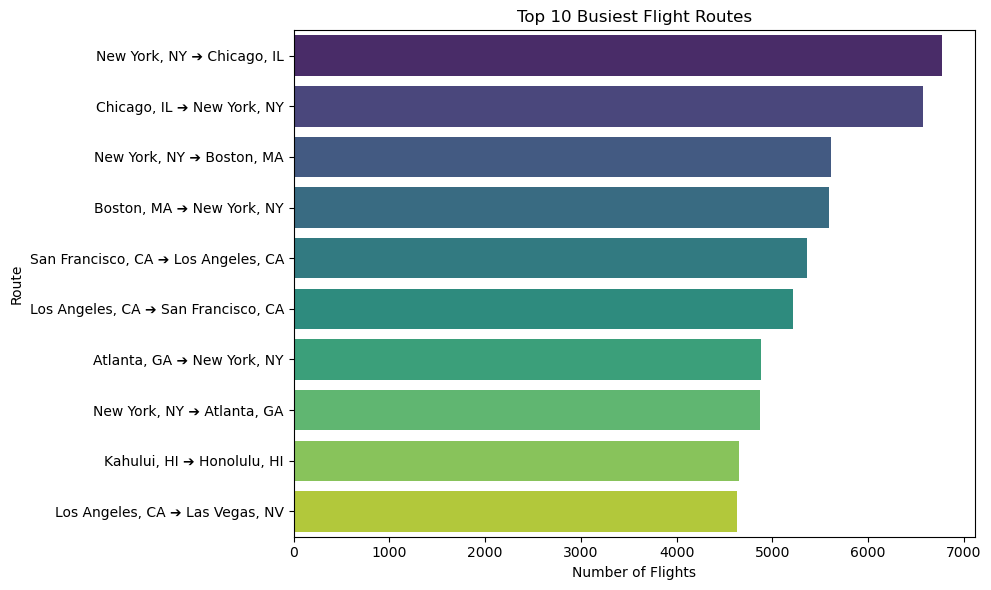

In [49]:
#week 5  Route and Airport-Level Analysis

#1. Top 10 Origin-Destination Pairs
#Identifying primary routes allows for the creation of a "Verified High-Speed Cache" for common paths.

import seaborn as sns
import matplotlib.pyplot as plt


df['Route'] = df['ORIGIN_CITY'] + ' ➔ ' + df['DEST_CITY']


top_routes = df['Route'].value_counts().head(10).reset_index()
top_routes.columns = ['Route', 'Number_of_Flights']


plt.figure(figsize=(10, 6))
sns.barplot(
    x='Number_of_Flights',
    y='Route',
    data=top_routes,
    hue='Route',         
    palette='viridis',
    dodge=False          
)
plt.legend([], [], frameon=False)  
plt.title('Top 10 Busiest Flight Routes')
plt.xlabel('Number of Flights')
plt.ylabel('Route')
plt.tight_layout()
plt.show()


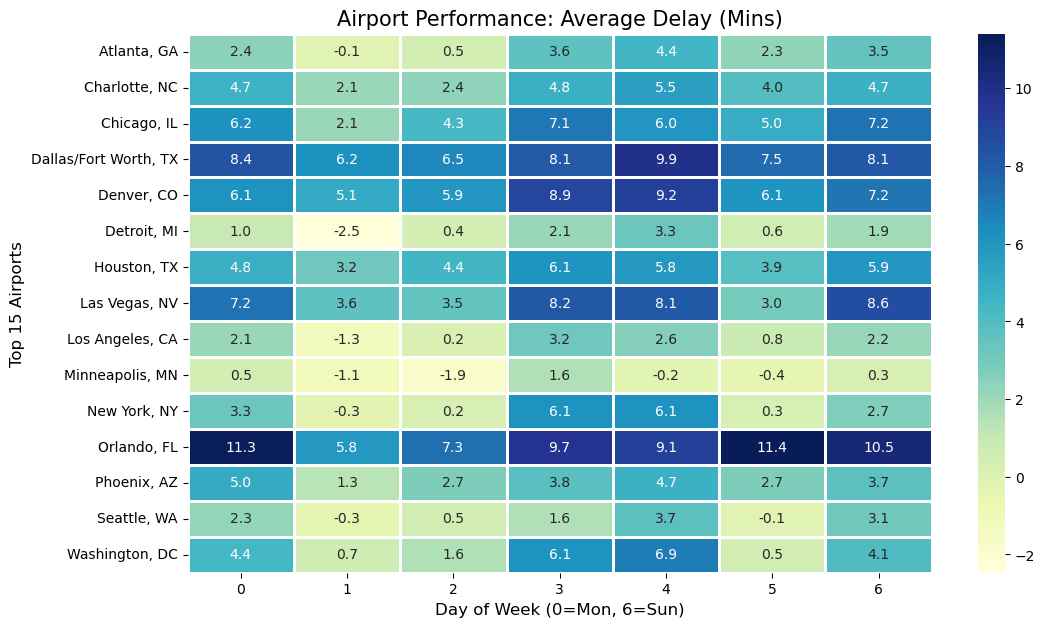

In [50]:
#2. Delay heatmaps by airport and route
#This heatmap provides a granular view of average arrival delays (in minutes) across different airports and days.

top_airports = df['ORIGIN_CITY'].value_counts().nlargest(15).index
clean_df = df[df['ORIGIN_CITY'].isin(top_airports)]


pivot_table = clean_df.pivot_table(index='ORIGIN_CITY', columns='DAY_OF_WEEK', values='ARR_DELAY', aggfunc='mean')


plt.figure(figsize=(12, 7))
sns.heatmap(pivot_table, 
            annot=True,          
            cmap='YlGnBu',       
            linewidths=2,        
            linecolor='white',   
            fmt=".1f")           

plt.title('Airport Performance: Average Delay (Mins)', fontsize=15)
plt.xlabel('Day of Week (0=Mon, 6=Sun)', fontsize=12)
plt.ylabel('Top 15 Airports', fontsize=12)
plt.show()

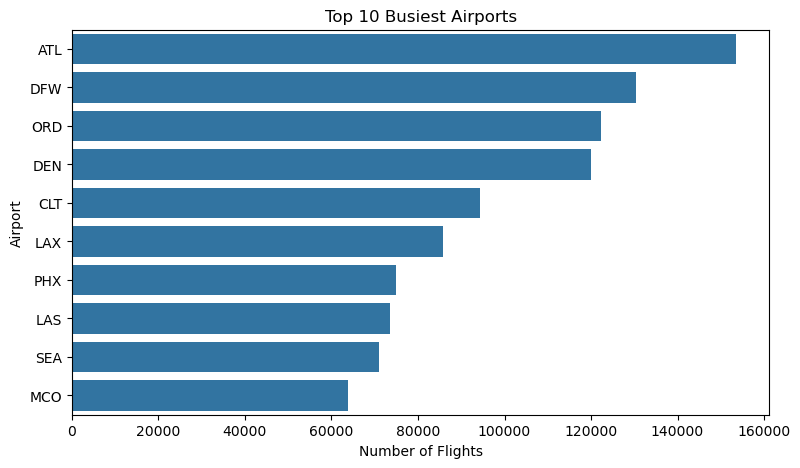

In [51]:
#Busiest Airports (Traffic Map → Bar Chart)
busiest_airports = (
    df.groupby("ORIGIN")
      .size()
      .reset_index(name="Total_Flights")
      .sort_values("Total_Flights", ascending=False)
      .head(10)
)

plt.figure(figsize=(9,5))
sns.barplot(data=busiest_airports, x="Total_Flights", y="ORIGIN")
plt.title("Top 10 Busiest Airports")
plt.xlabel("Number of Flights")
plt.ylabel("Airport")
plt.show()


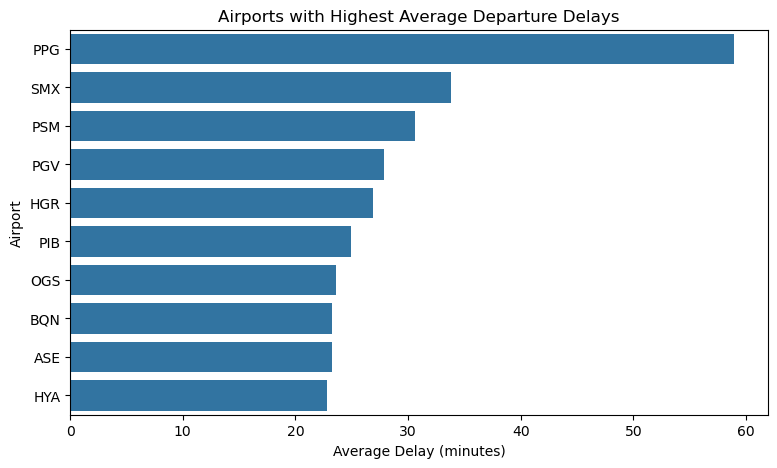

In [52]:
# Average Delay by Airport (Delay Severity Map)

avg_delay_airport = (
    df.groupby("ORIGIN")["DEP_DELAY"]
      .mean()
      .reset_index()
      .sort_values("DEP_DELAY", ascending=False)
      .head(10)
)

plt.figure(figsize=(9,5))
sns.barplot(data=avg_delay_airport, x="DEP_DELAY", y="ORIGIN")
plt.title("Airports with Highest Average Departure Delays")
plt.xlabel("Average Delay (minutes)")
plt.ylabel("Airport")
plt.show()


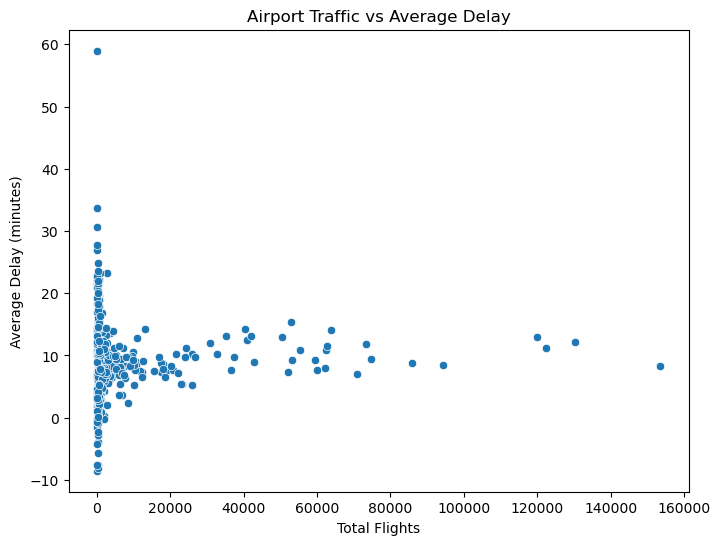

In [53]:
#Traffic vs Delay
airport_summary = (
    df.groupby("ORIGIN")
      .agg(
          Total_Flights=("FL_NUMBER", "count"),
          Avg_Delay=("DEP_DELAY", "mean")
      )
      .reset_index()
)

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=airport_summary,
    x="Total_Flights",
    y="Avg_Delay"
)

plt.title("Airport Traffic vs Average Delay")
plt.xlabel("Total Flights")
plt.ylabel("Average Delay (minutes)")
plt.show()

#High flight traffic does not necessarily lead to higher average delays; many busy airports operate efficiently with stable delay levels.
#Airports with low traffic show greater variability in delays, including extreme and inconsistent delay behavior.
#Overall, there is no strong correlation between airport traffic volume and average departure delay, indicating that delays are influenced by operational and external factors rather than traffic alone.


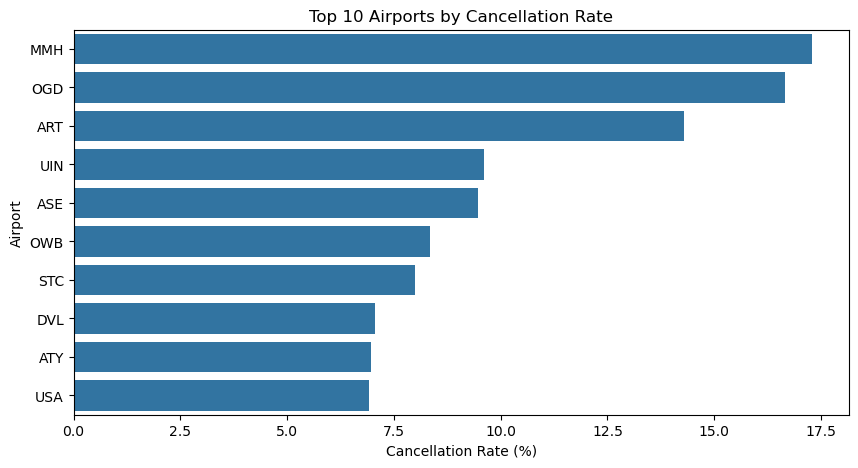

In [54]:
#week 6 Seasonal and Cancellation Analysis

#Cancellation Rate by Airport (Bar Chart)
cancel_rate = (
    df.groupby("ORIGIN")
      .agg(
          Total_Flights=("FL_NUMBER", "count"),
          Cancelled=("CANCELLED", "sum")
      )
      .reset_index()
)

cancel_rate["Cancel_Rate (%)"] = (
    cancel_rate["Cancelled"] / cancel_rate["Total_Flights"] * 100
)

cancel_rate = cancel_rate.sort_values("Cancel_Rate (%)", ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(data=cancel_rate, x="Cancel_Rate (%)", y="ORIGIN")
plt.title("Top 10 Airports by Cancellation Rate")
plt.xlabel("Cancellation Rate (%)")
plt.ylabel("Airport")
plt.show()




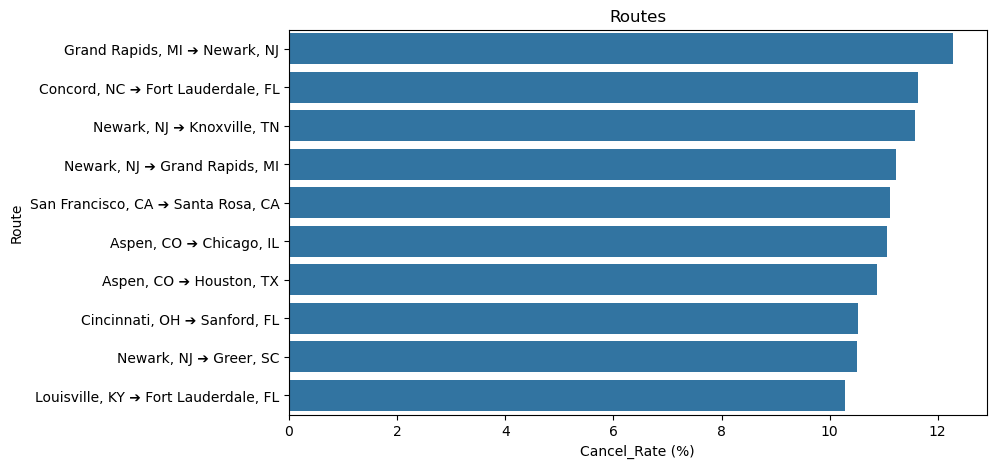

In [59]:
# route vs cancellation rate
#Cancellation Rate by Route (Bar Chart)
route_cancel = (
    df.groupby("Route")
      .agg(
          Total_Flights=("FL_NUMBER", "count"),
          Cancellations=("CANCELLED", "sum")
      )
      .reset_index()
)

# Filter meaningful routes
route_cancel = route_cancel[route_cancel["Total_Flights"] >= 100]

# Calculate cancellation rate
route_cancel["Cancel_Rate (%)"] = (
    route_cancel["Cancellations"] / route_cancel["Total_Flights"]
) * 100

# Top 10 routes by cancellation rate
top_routes = route_cancel.sort_values(
    "Cancel_Rate (%)", ascending=False
).head(10)

plt.figure(figsize=(9,5))
sns.barplot(data=top_routes, x="Cancel_Rate (%)", y="Route")
plt.title("Routes")
plt.show()



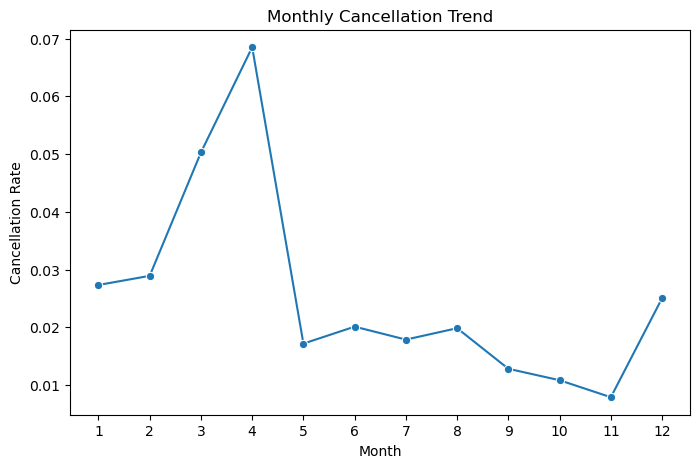

In [55]:
#Monthly Cancellation Trends
#How cancellations vary across months (seasonal impact).
monthly_cancellation = (
    df.groupby("MONTH")["CANCELLED"]
      .mean()
      .reset_index()
      .sort_values("MONTH")
)

plt.figure(figsize=(8,5))
sns.lineplot(
    data=monthly_cancellation,
    x="MONTH",
    y="CANCELLED",
    marker="o"
)

plt.xticks(range(1, 13))   # <-- forces display of all months

plt.title("Monthly Cancellation Trend")
plt.xlabel("Month")
plt.ylabel("Cancellation Rate")
plt.show()


# This line chart highlights seasonal patterns in flight cancellations across the year

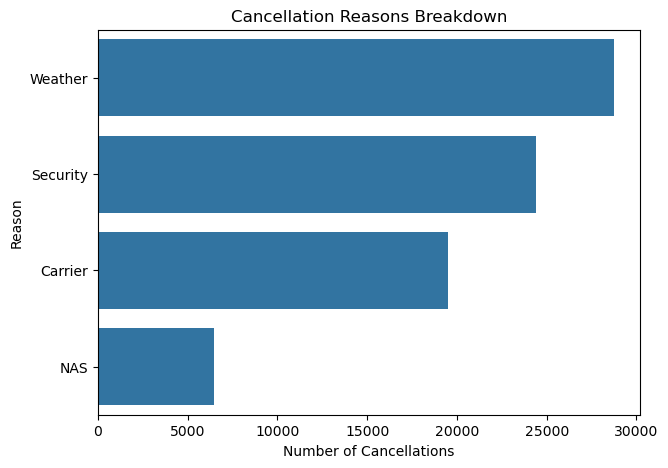

In [56]:
# Cancellation Types Breakdown
cancel_df = df[df["CANCELLED"] == 1]


cancel_reason_counts = (
    cancel_df["CANCELLATION_CODE"]
    .value_counts()
    .reset_index()
)


cancel_reason_counts.columns = ["Cancellation_Code", "Total"]


reason_map = {
    "A": "Carrier",
    "B": "Weather",
    "C": "NAS",
    "D": "Security"
}

cancel_reason_counts["Reason"] = cancel_reason_counts["Cancellation_Code"].map(reason_map)


plt.figure(figsize=(7,5))
sns.barplot(
    data=cancel_reason_counts,
    x="Total",
    y="Reason"
)

plt.title("Cancellation Reasons Breakdown")
plt.xlabel("Number of Cancellations")
plt.ylabel("Reason")
plt.show()

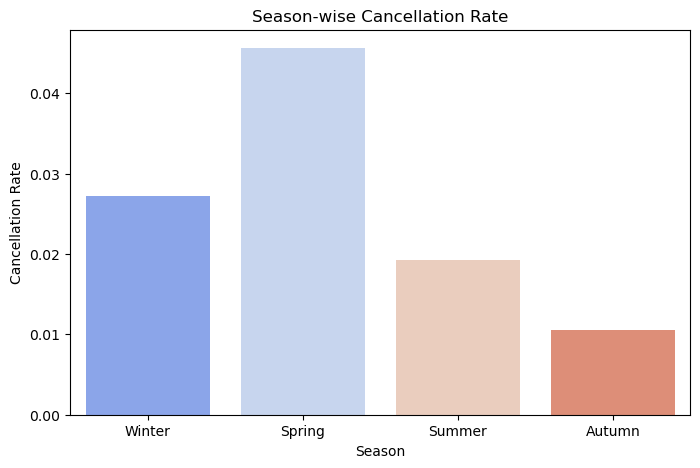

In [57]:
# Seasonal cancellations trend 
# Seasonal cancellations trend 
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["SEASON"] = df["MONTH"].apply(get_season)

seasonal_cancel = (
    df.groupby("SEASON")["CANCELLED"]
      .mean()
      .reset_index()
)

# Ensure correct order of seasons
season_order = ["Winter", "Spring", "Summer", "Autumn"]
seasonal_cancel["SEASON"] = pd.Categorical(seasonal_cancel["SEASON"], categories=season_order, ordered=True)
seasonal_cancel = seasonal_cancel.sort_values("SEASON")

# Plotting with future-proof Seaborn syntax
plt.figure(figsize=(8,5))
sns.barplot(
    data=seasonal_cancel,
    x="SEASON",
    y="CANCELLED",
    hue="SEASON",       # Assign x variable to hue to avoid warning
    palette="coolwarm",
    dodge=False          # Avoid splitting bars
)
plt.legend([], [], frameon=False)  # Hide legend
plt.title("Season-wise Cancellation Rate")
plt.xlabel("Season")
plt.ylabel("Cancellation Rate")
plt.show()


# Spring shows the highest delays, likely due to volatile weather, increased travel, or operational factors, rather than winter conditions.


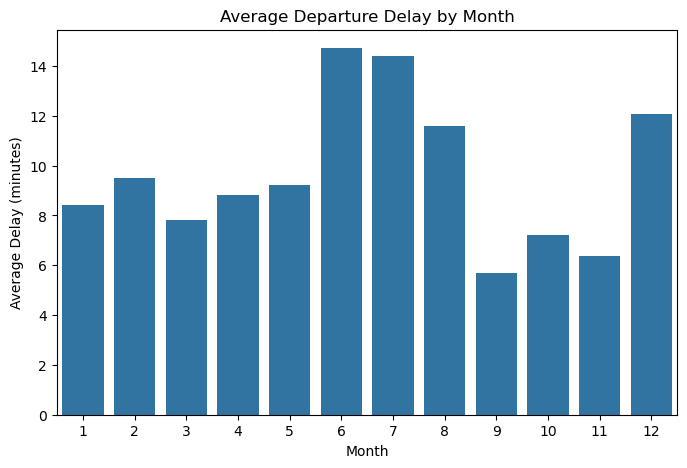

In [58]:
# average delay by month

monthly_delay = (
    df.groupby("MONTH")["DEP_DELAY"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(8,5))
sns.barplot(data=monthly_delay, x="MONTH", y="DEP_DELAY")
plt.title("Average Departure Delay by Month")
plt.xlabel("Month")
plt.ylabel("Average Delay (minutes)")
plt.show()

#Delays peak in June and July might be due to high traffic and weather
#December shows higher delays likely linked to winter holiday travel